# SpaceX Falcon 9 Exploratory Data Analysis


This notebook analyzes SpaceX Falcon 9 launch data to explore factors affecting first-stage landing success and build predictive models.


## Objective
- Visualize how launch site, orbit, payload mass, and flight history relate to landing outcomes.
- Prepare a one-hot encoded feature matrix for downstream modeling.
- Save the transformed features to `data/dataset_part_3.csv`.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    candidate
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / "data").exists() and (candidate / "notebooks").exists()
)
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.append(str(NOTEBOOKS_DIR))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from notebook_utils import data_path, ensure_binary_file

sns.set_theme(style="whitegrid")


## Data Loading


In [2]:
DATASET_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
)
dataset_path = data_path("dataset_part_2.csv")
if not dataset_path.exists():
    dataset_path = ensure_binary_file("dataset_part_2.csv", DATASET_URL)

df = pd.read_csv(dataset_path)
df.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


## Exploratory Data Analysis


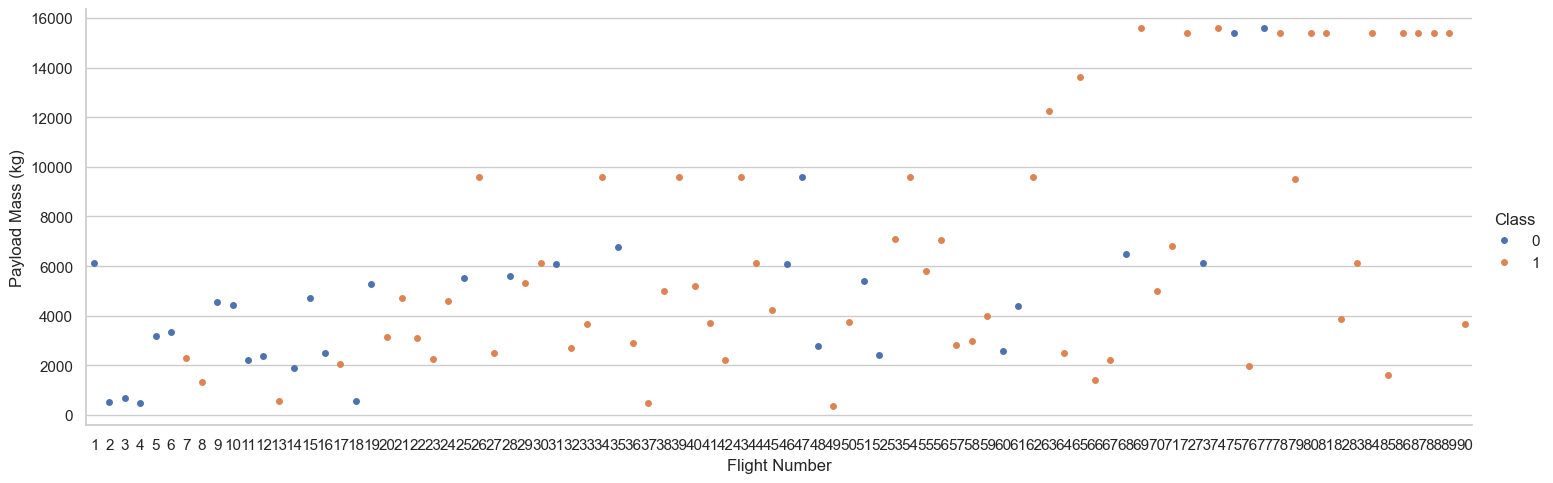

In [3]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=3)
plt.xlabel("Flight Number")
plt.ylabel("Payload Mass (kg)")
plt.show()


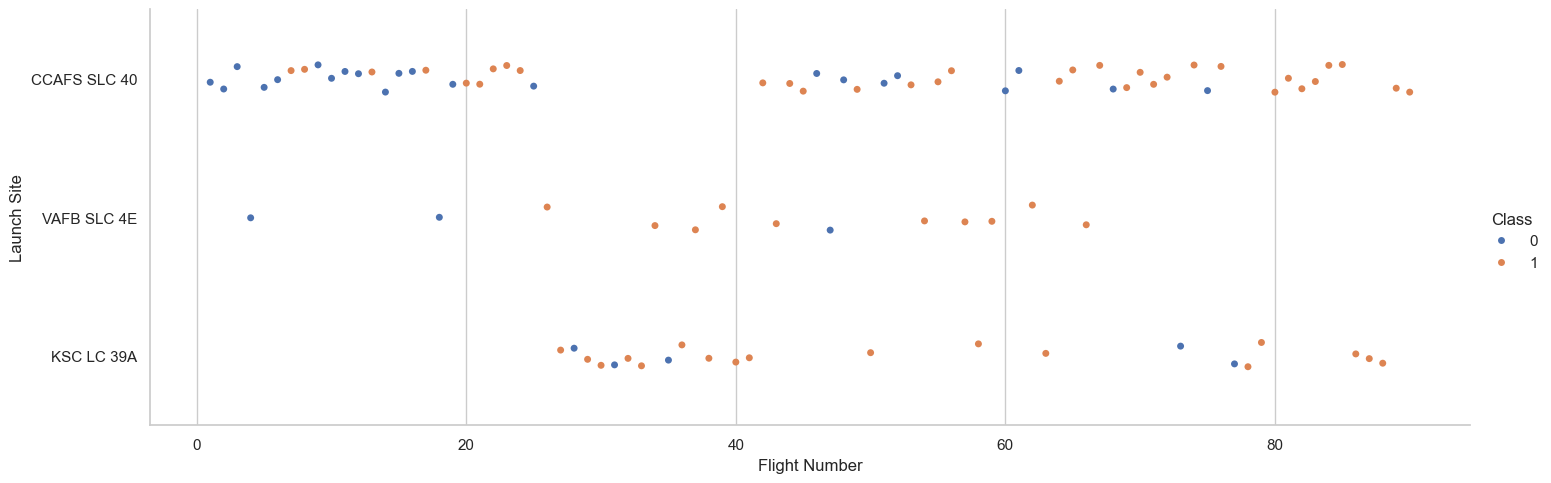

In [4]:
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=3)
plt.xlabel("Flight Number")
plt.ylabel("Launch Site")
plt.show()


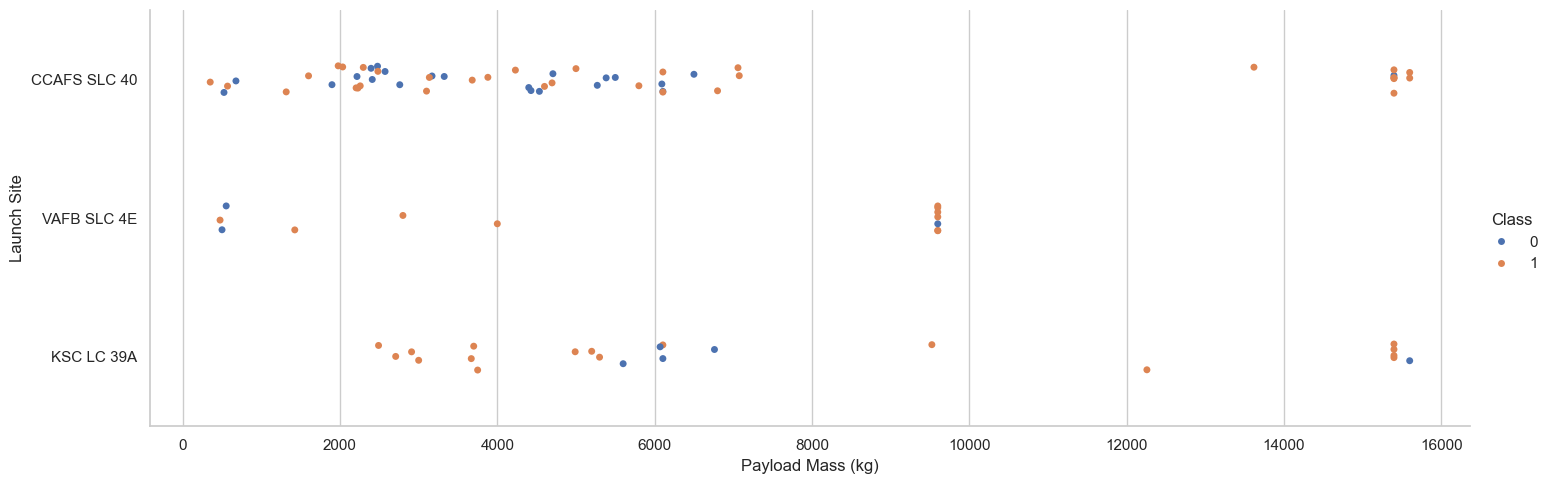

In [5]:
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=3)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Launch Site")
plt.show()


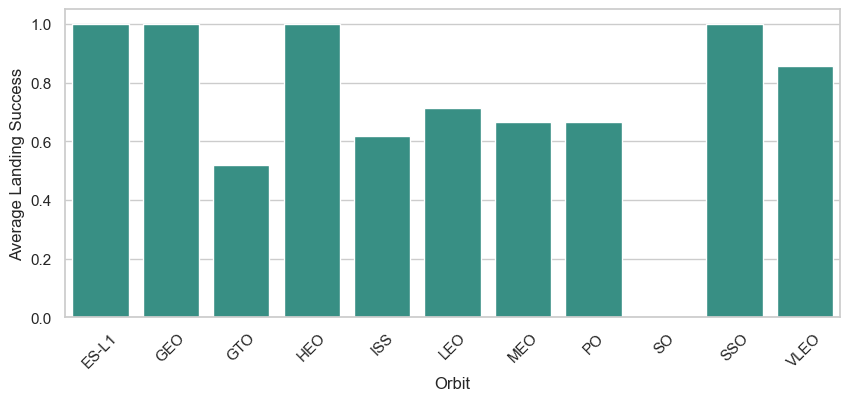

In [6]:
orbit_success = df.groupby("Orbit", as_index=False)["Class"].mean()
plt.figure(figsize=(10, 4))
sns.barplot(data=orbit_success, x="Orbit", y="Class", color="#2a9d8f")
plt.xlabel("Orbit")
plt.ylabel("Average Landing Success")
plt.xticks(rotation=45)
plt.show()


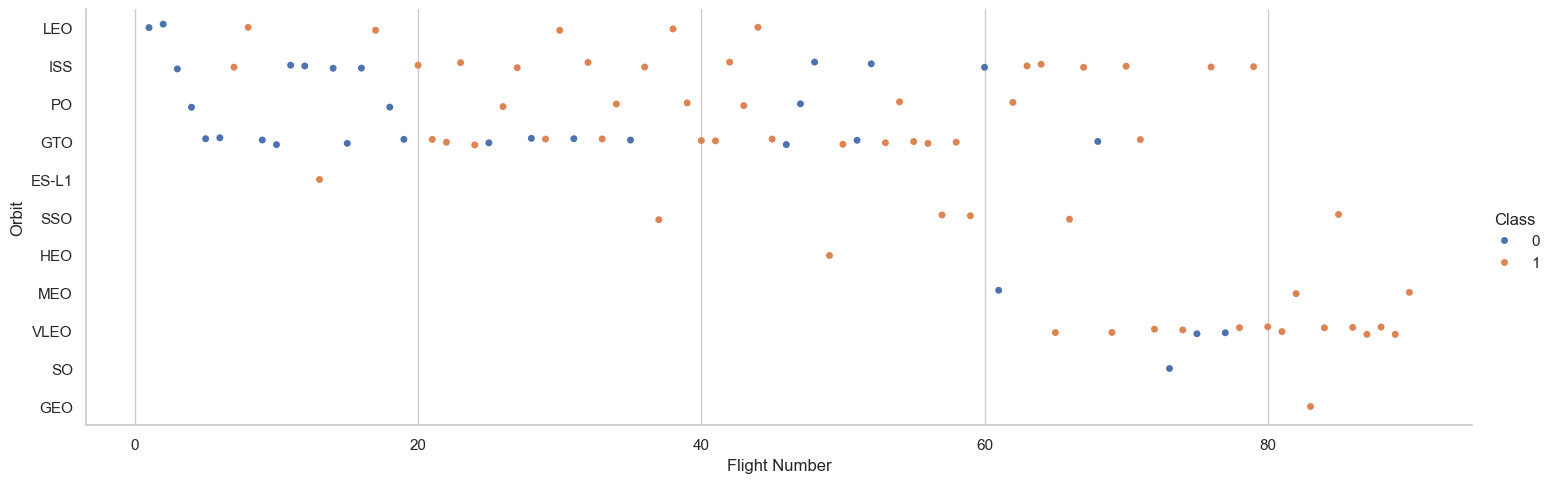

In [7]:
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=3)
plt.xlabel("Flight Number")
plt.ylabel("Orbit")
plt.show()


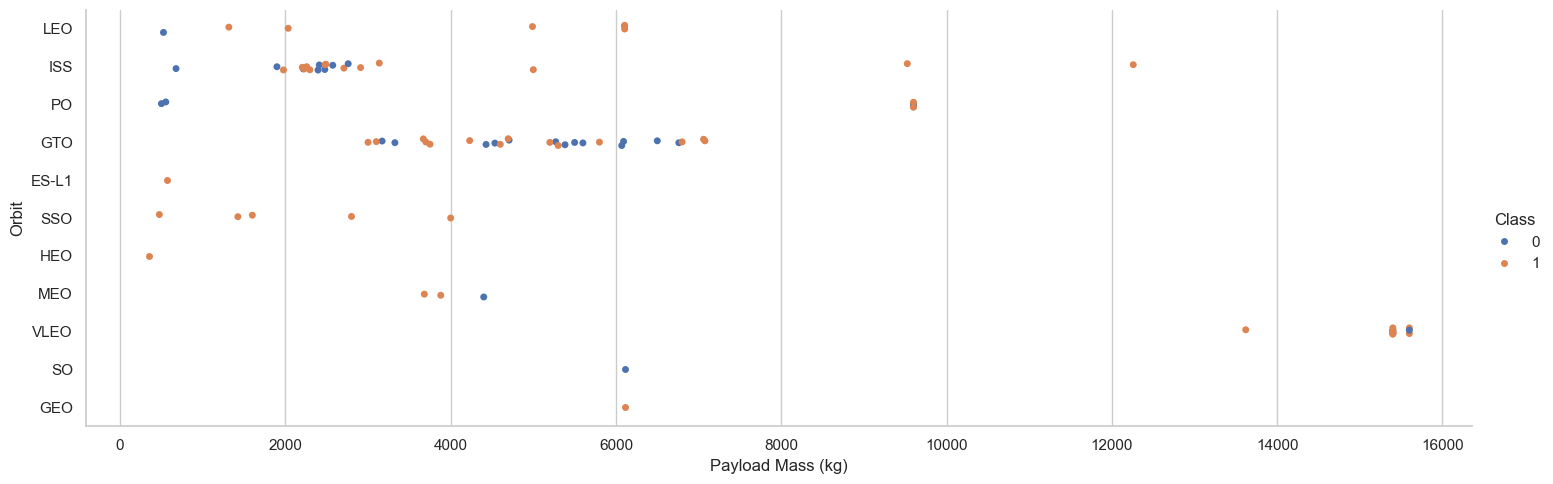

In [8]:
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=3)
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit")
plt.show()


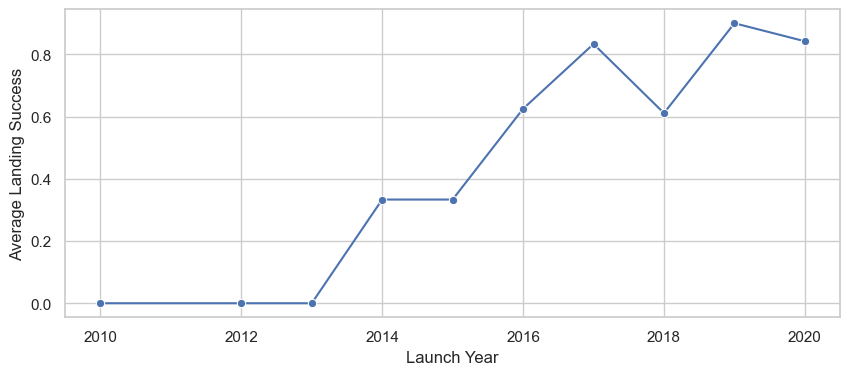

In [9]:
df["Year"] = pd.to_datetime(df["Date"]).dt.year
yearly_success = df.groupby("Year", as_index=False)["Class"].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(data=yearly_success, x="Year", y="Class", marker="o")
plt.xlabel("Launch Year")
plt.ylabel("Average Landing Success")
plt.show()


## Feature Engineering


In [10]:
features = df[[
    "FlightNumber",
    "PayloadMass",
    "Orbit",
    "LaunchSite",
    "Flights",
    "GridFins",
    "Reused",
    "Legs",
    "LandingPad",
    "Block",
    "ReusedCount",
    "Serial",
]].copy()

features_one_hot = pd.get_dummies(
    features,
    columns=["Orbit", "LaunchSite", "LandingPad", "Serial"],
).astype("float64")
features_one_hot.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
output_path = data_path("dataset_part_3.csv")
features_one_hot.to_csv(output_path, index=False)
output_path


PosixPath('/Users/riyana/Desktop/spacex/data/dataset_part_3.csv')

## Key Findings


In [12]:
orbit_success.sort_values("Class", ascending=False)


,Orbit,Class
0,ES-L1,1.000000
1,GEO,1.000000
3,HEO,1.000000
9,SSO,1.000000
10,VLEO,0.857143
5,LEO,0.714286
6,MEO,0.666667
7,PO,0.666667
4,ISS,0.619048
2,GTO,0.518519
